(np.float64(20.116292958733073),
 np.float64(20.107238605898125),
 np.float64(0.029999972359543173))

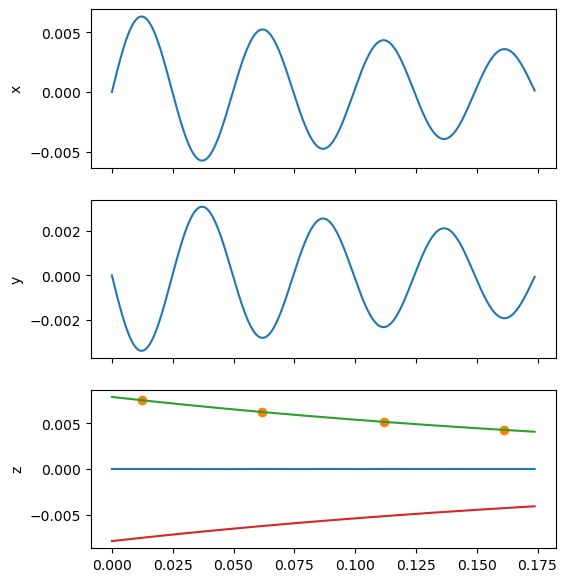

In [2]:
import numpy as np
import matplotlib.pylab as plt
from scipy.signal import find_peaks

disp = np.loadtxt("sweep_03.csv", delimiter=",")
x = (
    np.array(
        [
            0.0,
            0.08488805186071652,
            0.2655756032646429,
            0.5,
            0.7344243967353571,
            0.9151119481392835,
            1.0,
        ]
    )
    * 10.0
)

# fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True)
# for row in dat:
#     ax[0].plot(x, row[1::3])
#     ax[1].plot(x, row[2::3])
#     ax[2].plot(x, row[3::3])

i_max = np.argmax(np.max(disp[:,1:], axis=0))+1

peaks_p = find_peaks(disp[:,i_max])[0]

t = disp[:, 0]
t_peaks = t[peaks_p]
T = np.diff(t_peaks).mean()
x = disp[peaks_p, i_max]
n = (t_peaks[-1] - t_peaks[0]) / T
dec = np.log(x[0] / x[-1]) / n
zeta = dec / np.sqrt(4 * np.pi**2 + dec**2)
fd = 1 / T
fn = fd / np.sqrt(1.0 - zeta**2)
A = x[0] / np.exp(-np.pi * 2 * fn * zeta * t_peaks[0])

fig, ax = plt.subplots(3, figsize=(6, 7), sharex=True)
ax[0].plot(t, disp[:, -3])
ax[1].plot(t, disp[:, -2])
ax[2].plot(t, disp[:, -1])
ax[0].set_ylabel('x')
ax[1].set_ylabel('y')
ax[2].set_ylabel('z')
ax[i_max%3-1].plot(t[peaks_p], disp[peaks_p,i_max], 'o')
ax[i_max%3-1].plot(t, A*np.exp(-np.pi*2*fn*zeta*t))
ax[i_max%3-1].plot(t, -A*np.exp(-np.pi*2*fn*zeta*t))

# mu = 2 * zeta / (np.pi * 2 * fn)
fn, fd, zeta